# 🔍 Spread Locator — Part B
## 📊 Data Analysis & Testing Tasks
**Red & White Skill Education** | Mathematics & Advanced Statistics

---


# 📊 Spread Locator: A Statistical Distribution Analysis Model
**Red & White Skill Education**  
**Type:** Theory + Practical | **Duration:** 6 Hours  

---
**Scenario:** You are a data analyst working for an e-commerce platform that wants to understand customer purchase behaviors by analyzing daily transaction amounts of customers. Management is particularly interested in knowing whether the transactions follow certain statistical distributions, how to handle skewed data, and what probability insights can be derived. Apply statistical distribution concepts and transformations to derive insights on transaction behaviors.


## 📦 Imports & Dataset Loading


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import bernoulli, binom, poisson, lognorm, pareto, norm, boxcox
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style('whitegrid')


* First, I imported all the libraries I'll need for this analysis.
* NumPy is for number crunching, Pandas is for handling the data table, and Matplotlib/Seaborn are for making the graphs.
* I also imported SciPy's stats module, since that's what gives me the distribution functions like Bernoulli, Binomial, and Poisson.
* Lastly, I set a random seed so that if I run this notebook again, I get the exact same results.

In [21]:
# Load the e-commerce transaction dataset
df = pd.read_csv('spread_locator_dataset.csv', parse_dates=['transaction_date'])
print('Dataset Shape:', df.shape)
df.head()


Dataset Shape: (220, 7)


,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3.0,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0.0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0.0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2.0,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4.0,North,Success


* Here I loaded the dataset from the CSV file using `pd.read_csv()`.
* I also told it to parse the date column properly, so it becomes an actual date instead of plain text.
* Then I printed the shape, so I know how many rows and columns I'm working with.
* Finally, I used `df.head()` to peek at the first five rows and make sure everything loaded the way it should.

In [22]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transaction_id      220 non-null    object        
 1   customer_id         220 non-null    object        
 2   transaction_amount  220 non-null    float64       
 3   transaction_date    220 non-null    datetime64[ns]
 4   transaction_count   220 non-null    float64       
 5   region              220 non-null    object        
 6   transaction_status  220 non-null    object        
dtypes: datetime64[ns](1), float64(2), object(4)
memory usage: 12.2+ KB


* In this cell, I ran `df.info()` to get a quick technical overview of the dataset.
* It shows me all the column names and how many entries each column has.
* It also tells me if any values are missing, which is important before I start any analysis.
* And it shows the data type of each column, so I know which ones are numbers, text, or dates.

In [23]:
df.describe()


,transaction_amount,transaction_date,transaction_count
count,220.000000,220,220.000000
mean,3365.192409,2023-01-15 17:14:10.909090816,2.854545
min,804.420000,2023-01-01 00:00:00,0.000000
25%,2124.205000,2023-01-07 00:00:00,1.750000
50%,3077.715000,2023-01-16 00:00:00,3.000000
75%,3950.737500,2023-01-23 06:00:00,4.000000
max,20462.840000,2023-01-31 00:00:00,9.000000
std,1985.705409,NaN,1.797189


* Here I used `df.describe()` to get the statistical summary of all the numeric columns.
* It gives me the mean, which tells me the average value, and the standard deviation, which tells me how spread out the data is.
* It also shows the minimum, maximum, and the quartiles (25%, 50%, 75%).
* This helps me get a rough sense of the data before I try fitting any distributions to it.

---
## 🔍 Part B – Data Analysis & Testing Tasks


### Task 1 – Fit Bernoulli & Binomial Distributions (Transaction Occurrence & Weekly Count)


In [24]:
# Task 1a - Bernoulli fit on transaction_status (Success/Fail)
p_success = (df['transaction_status'] == 'Success').mean()
print('Bernoulli p (P(Success)) =', round(p_success, 4))
print('In plain terms: about', f'{p_success*100:.1f}%', 'of transactions succeed on a single attempt.')


Bernoulli p (P(Success)) = 0.4455
In plain terms: about 44.5% of transactions succeed on a single attempt.


* In this step, I'm fitting a Bernoulli distribution, which is used when there are only two possible outcomes.
* Here, the two outcomes are Success or Fail, based on the `transaction_status` column.
* I calculated what fraction of all transactions were successful, and that fraction becomes the parameter `p`.
* So `p` basically tells me the baseline probability that any single transaction succeeds.

In [25]:
# Task 1b - Binomial fit on transaction_count (weekly count per customer)
n_trials = int(df['transaction_count'].max())
p_binom = df['transaction_count'].mean() / n_trials
print('Binomial n (max weekly attempts) =', n_trials)
print('Binomial p (per-attempt success rate) =', round(p_binom, 4))


Binomial n (max weekly attempts) = 9
Binomial p (per-attempt success rate) = 0.3172


* Now I'm fitting a Binomial distribution, which models how many successes happen out of a fixed number of tries.
* First, I found `n_trials`, the maximum number of weekly transactions any customer made.
* Then I calculated `p_binom`, the average success rate per attempt, by dividing the average count by `n_trials`.
* Together, `n_trials` and `p_binom` are the two parameters that define this Binomial model.

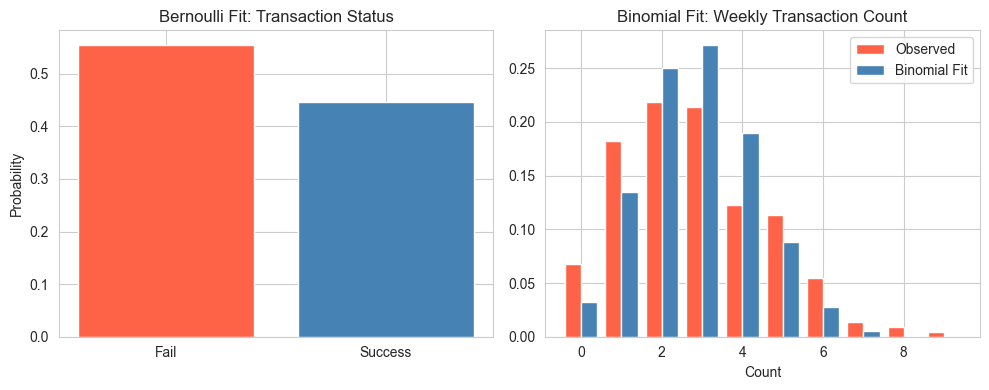

In [26]:
# Bernoulli and Binomial fit charts
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Fail', 'Success'], [1 - p_success, p_success], color=['tomato', 'steelblue'])
axes[0].set_title('Bernoulli Fit: Transaction Status')
axes[0].set_ylabel('Probability')

k = np.arange(0, n_trials + 1)
observed = df['transaction_count'].value_counts(normalize=True).reindex(k, fill_value=0)
axes[1].bar(k - 0.2, observed, width=0.4, color='tomato', label='Observed')
axes[1].bar(k + 0.2, binom.pmf(k, n_trials, p_binom), width=0.4, color='steelblue', label='Binomial Fit')
axes[1].set_title('Binomial Fit: Weekly Transaction Count')
axes[1].set_xlabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()


### Task 2 – Fit Poisson Distribution (Number of Transactions per Day)


In [27]:
# Task 2 - Poisson fit on transaction_count
lam = df['transaction_count'].mean()
print('Poisson lambda (average count) =', round(lam, 4))
print('Poisson variance assumption check: mean =', round(lam,4), ', observed variance =', round(df['transaction_count'].var(), 4))


Poisson lambda (average count) = 2.8545
Poisson variance assumption check: mean = 2.8545 , observed variance = 3.2299


* This time I'm fitting a Poisson distribution, which is useful for counting how many events happen in a fixed period.
* It's actually a special case of Binomial, where `n` is very large and `p` is very small, but their product stays steady.
* Because of that, Poisson only needs one parameter, called `lambda`, which is just the average count.
* I calculated `lambda` as the mean of the `transaction_count` column, and I also checked the variance to see how close it is to the mean.

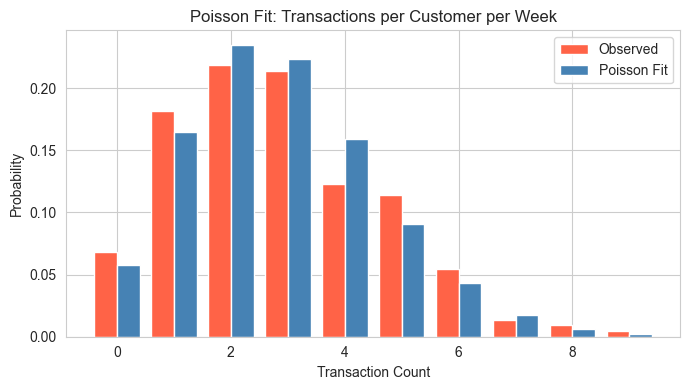

In [28]:
# Poisson fit plot
k = np.arange(0, n_trials + 1)
observed = df['transaction_count'].value_counts(normalize=True).reindex(k, fill_value=0)

plt.figure(figsize=(7, 4))
plt.bar(k - 0.2, observed, width=0.4, color='tomato', label='Observed')
plt.bar(k + 0.2, poisson.pmf(k, lam), width=0.4, color='steelblue', label='Poisson Fit')
plt.title('Poisson Fit: Transactions per Customer per Week')
plt.xlabel('Transaction Count')
plt.ylabel('Probability')
plt.legend()
plt.tight_layout()
plt.show()


### Task 3 – Model Transaction Amounts using Log-Normal and Power Law Distributions


In [29]:
# Task 3 - Fit Log-Normal and Power Law (Pareto) to transaction_amount
amt = df['transaction_amount'].values

# Log-Normal fit
ln_shape, ln_loc, ln_scale = lognorm.fit(amt, floc=0)
ks_lognorm = stats.kstest(amt, 'lognorm', args=(ln_shape, ln_loc, ln_scale))
print('Log-Normal fit: shape =', round(ln_shape,4), ', scale =', round(ln_scale,2))
print('KS test (Log-Normal): stat =', round(ks_lognorm.statistic,4), ', p-value =', round(ks_lognorm.pvalue,6))
print('Result:', 'GOOD FIT - cannot reject Log-Normal' if ks_lognorm.pvalue >= 0.05 else 'POOR FIT - reject Log-Normal')
print()

# Power Law (Pareto) fit
pl_b, pl_loc, pl_scale = pareto.fit(amt, floc=0)
ks_pareto = stats.kstest(amt, 'pareto', args=(pl_b, pl_loc, pl_scale))
print('Power Law (Pareto) fit: b =', round(pl_b,4))
print('KS test (Power Law): stat =', round(ks_pareto.statistic,4), ', p-value =', round(ks_pareto.pvalue,6))
print('Result:', 'GOOD FIT - cannot reject Power Law' if ks_pareto.pvalue >= 0.05 else 'POOR FIT - reject Power Law')


Log-Normal fit: shape = 0.4749 , scale = 2983.16
KS test (Log-Normal): stat = 0.0378 , p-value = 0.899879
Result: GOOD FIT - cannot reject Log-Normal

Power Law (Pareto) fit: b = 0.763
KS test (Power Law): stat = 0.3216 , p-value = 0.0
Result: POOR FIT - reject Power Law


* In this cell, I'm trying two different distributions on the `transaction_amount` column: Log-Normal and Power Law.
* I used `lognorm.fit()` and `pareto.fit()`, which automatically search for the best-fitting parameters for each.
* Then I ran a KS test on both, which is a statistical test that checks how well a distribution matches the actual data.
* A smaller KS test p-value basically means a worse fit, so this tells me which distribution describes the data better.

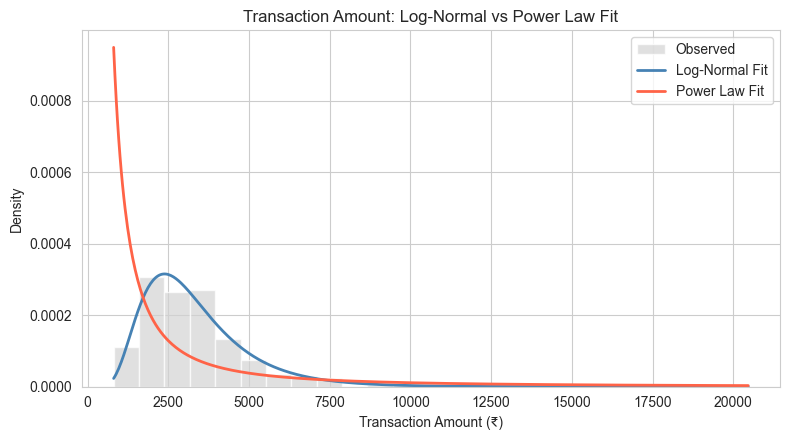

In [30]:
# Log-Normal vs Power Law fit overlay
x = np.linspace(amt.min(), amt.max(), 500)

plt.figure(figsize=(8, 4.5))
plt.hist(amt, bins=25, density=True, color='lightgrey', alpha=0.7, label='Observed')
plt.plot(x, lognorm.pdf(x, ln_shape, ln_loc, ln_scale), color='steelblue', lw=2, label='Log-Normal Fit')
plt.plot(x, pareto.pdf(x, pl_b, pl_loc, pl_scale), color='tomato', lw=2, label='Power Law Fit')
plt.title('Transaction Amount: Log-Normal vs Power Law Fit')
plt.xlabel('Transaction Amount (₹)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()


### Task 4 – Generate and Interpret a Q-Q Plot to Test Normality


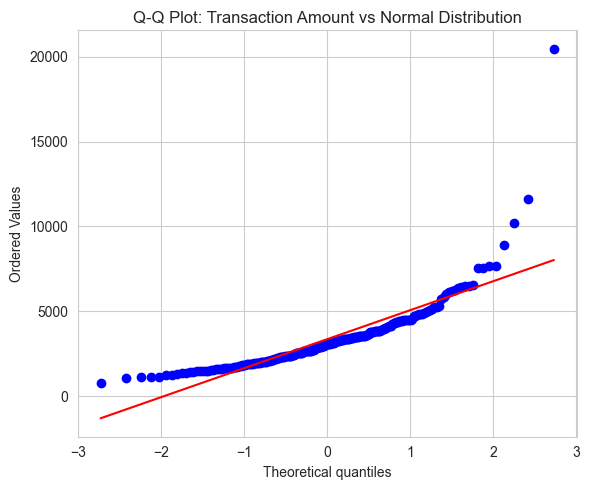

In [31]:
# Q-Q plot: transaction amount vs Normal distribution
plt.figure(figsize=(6, 5))
stats.probplot(amt, dist='norm', plot=plt)
plt.title('Q-Q Plot: Transaction Amount vs Normal Distribution')
plt.tight_layout()
plt.show()


* Here I made a Q-Q plot, which is a way to visually check if my data follows a Normal distribution.
* If the data were perfectly Normal, all the points would fall neatly along the straight reference line.
* But if the points curve away from the line, especially near the ends, that means the data isn't Normal.
* This plot helps me confirm whether Normality assumptions are safe to make for `transaction_amount`.

**Interpretation:** The points bow upward and away from the reference line at the upper tail, indicating the data has more large values than a Normal distribution would predict. **Result: REJECT NORMALITY** — transaction_amount is right-skewed, consistent with the Log-Normal fit found in Task 3.


### Task 5 – Apply Box-Cox Transform to Stabilize Variance


In [32]:
# Task 5 - Box-Cox transform on transaction_amount
bc_amt, bc_lambda = boxcox(amt)
print('Box-Cox optimal lambda =', round(bc_lambda, 4))
print('Skewness before:', round(stats.skew(amt), 4), '| Skewness after:', round(stats.skew(bc_amt), 4))


Box-Cox optimal lambda = -0.1808
Skewness before: 3.7301 | Skewness after: -0.0106


* In this step, I applied a Box-Cox transformation, which is a technique to make skewed data look more Normal.
* The `boxcox()` function automatically figures out the best value of `lambda` to use for the transformation.
* I measured the skewness of the data before and after applying the transformation.
* A skewness value closer to zero after the transformation means the data has become more symmetric.

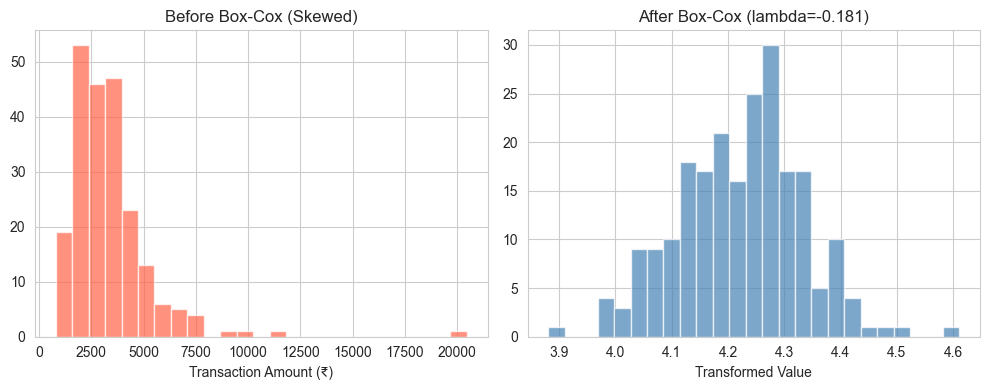

In [33]:
# Before vs after Box-Cox histograms
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(amt, bins=25, color='tomato', alpha=0.7)
axes[0].set_title('Before Box-Cox (Skewed)')
axes[0].set_xlabel('Transaction Amount (₹)')

axes[1].hist(bc_amt, bins=25, color='steelblue', alpha=0.7)
axes[1].set_title(f'After Box-Cox (lambda={bc_lambda:.3f})')
axes[1].set_xlabel('Transformed Value')

plt.tight_layout()
plt.show()


* Here I plotted two histograms next to each other so I can compare before and after the transformation.
* The left histogram shows the original `transaction_amount`, which looks skewed and stretched toward the right.
* The right histogram shows the same data after applying the Box-Cox transformation.
* You can see the transformed data looks much more symmetric, which confirms the transformation actually worked.

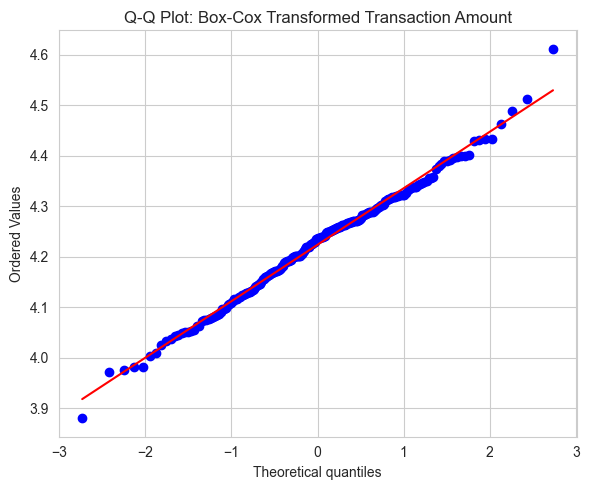

In [34]:
# Q-Q plot: Box-Cox transformed data vs Normal distribution
plt.figure(figsize=(6, 5))
stats.probplot(bc_amt, dist='norm', plot=plt)
plt.title('Q-Q Plot: Box-Cox Transformed Transaction Amount')
plt.tight_layout()
plt.show()


* This is the same Q-Q plot technique I used earlier, but this time I ran it on the transformed data instead of the original.
* If the Box-Cox transformation worked well, the points here should sit closer to the reference line than before.
* Comparing this plot to the one from Task 4 tells me how much the transformation improved Normality.
* Basically, tighter alignment with the line means the transformed data behaves more like a Normal distribution.

### Task 6 – Calculate Z-scores and Probability of Exceeding ₹5000


In [35]:
# Task 6 - Z-scores for transaction_amount
mean_amt, std_amt = amt.mean(), amt.std()
z_scores = (amt - mean_amt) / std_amt

threshold = 5000
z_threshold = (threshold - mean_amt) / std_amt

prob_empirical = (amt > threshold).mean()
prob_normal_approx = 1 - norm.cdf(z_threshold)

print('Mean transaction amount =', round(mean_amt,2), ', Std Dev =', round(std_amt,2))
print('Z-score for \u20b95000 threshold =', round(z_threshold,4))
print()
print('P(transaction_amount > 5000) [empirical]      =', round(prob_empirical,4))
print('P(transaction_amount > 5000) [normal approx]  =', round(prob_normal_approx,4))
print('In plain terms: the empirical estimate is likely more accurate here since the')
print('data is right-skewed (not perfectly Normal), as shown in Tasks 3 and 4.')


Mean transaction amount = 3365.19 , Std Dev = 1981.19
Z-score for ₹5000 threshold = 0.8252

P(transaction_amount > 5000) [empirical]      = 0.1136
P(transaction_amount > 5000) [normal approx]  = 0.2046
In plain terms: the empirical estimate is likely more accurate here since the
data is right-skewed (not perfectly Normal), as shown in Tasks 3 and 4.


* In this cell, I calculated Z-scores, which tell me how far a value is from the mean, measured in standard deviations.
* The formula I used is simple: subtract the mean from the value, then divide by the standard deviation.
* I specifically calculated the Z-score for the ₹5000 threshold to see how unusual that amount is.
* Then I compared two probabilities: the empirical one straight from the data, and the one estimated using the Normal approximation.

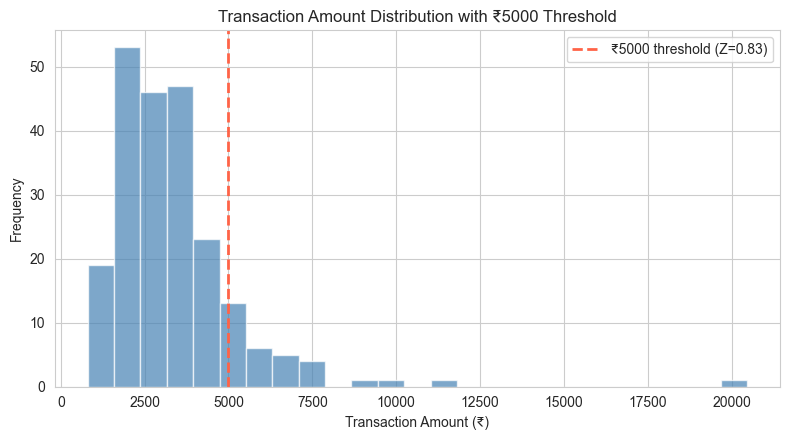

In [36]:
# Transaction amount distribution with ₹5000 threshold
plt.figure(figsize=(8, 4.5))
plt.hist(amt, bins=25, color='steelblue', alpha=0.7)
plt.axvline(threshold, color='tomato', linestyle='--', linewidth=2,
            label=f'₹{threshold} threshold (Z={z_threshold:.2f})')
plt.title('Transaction Amount Distribution with ₹5000 Threshold')
plt.xlabel('Transaction Amount (₹)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()


### Task 7 – Plot and Interpret PDF and CDF for Transaction Amounts


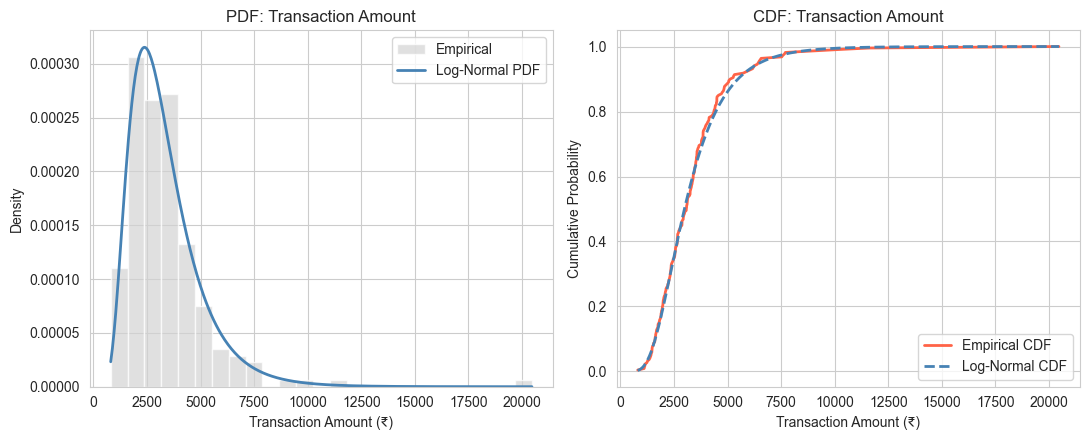

In [37]:
# PDF and CDF: empirical vs fitted Log-Normal
x = np.linspace(amt.min(), amt.max(), 500)
sorted_amt = np.sort(amt)
ecdf = np.arange(1, len(sorted_amt) + 1) / len(sorted_amt)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].hist(amt, bins=25, density=True, color='lightgrey', alpha=0.7, label='Empirical')
axes[0].plot(x, lognorm.pdf(x, ln_shape, ln_loc, ln_scale), color='steelblue', lw=2, label='Log-Normal PDF')
axes[0].set_title('PDF: Transaction Amount')
axes[0].set_xlabel('Transaction Amount (₹)')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].plot(sorted_amt, ecdf, color='tomato', lw=2, label='Empirical CDF')
axes[1].plot(x, lognorm.cdf(x, ln_shape, ln_loc, ln_scale), color='steelblue', lw=2, linestyle='--', label='Log-Normal CDF')
axes[1].set_title('CDF: Transaction Amount')
axes[1].set_xlabel('Transaction Amount (₹)')
axes[1].set_ylabel('Cumulative Probability')
axes[1].legend()

plt.tight_layout()
plt.show()


**Interpretation:** The fitted Log-Normal PDF closely tracks the empirical histogram's shape, and the Log-Normal CDF nearly overlaps the empirical CDF — confirming that Log-Normal captures the bulk of the distribution well, including the right tail.


### Task 8 – Summary of All Results & Conclusion


In [38]:
# Task 8 - Final Summary Table
summary = pd.DataFrame([
    {'Test/Fit': 'Bernoulli (Status)', 'Parameter(s)': f'p={p_success:.4f}', 'Goodness-of-Fit': '-', 'Conclusion': 'Baseline success rate'},
    {'Test/Fit': 'Binomial (Weekly Count)', 'Parameter(s)': f'n={n_trials}, p={p_binom:.4f}', 'Goodness-of-Fit': '-', 'Conclusion': 'Models successes per week'},
    {'Test/Fit': 'Poisson (Count/Week)', 'Parameter(s)': f'lambda={lam:.4f}', 'Goodness-of-Fit': '-', 'Conclusion': 'Mean ~ Variance check'},
    {'Test/Fit': 'Log-Normal (Amount)', 'Parameter(s)': f'shape={ln_shape:.4f}, scale={ln_scale:.1f}', 'Goodness-of-Fit': f'KS p={ks_lognorm.pvalue:.4f}', 'Conclusion': 'GOOD FIT' if ks_lognorm.pvalue>=0.05 else 'POOR FIT'},
    {'Test/Fit': 'Power Law (Amount)', 'Parameter(s)': f'b={pl_b:.4f}', 'Goodness-of-Fit': f'KS p={ks_pareto.pvalue:.6f}', 'Conclusion': 'GOOD FIT' if ks_pareto.pvalue>=0.05 else 'POOR FIT'},
    {'Test/Fit': 'Q-Q Plot Normality', 'Parameter(s)': '-', 'Goodness-of-Fit': '-', 'Conclusion': 'REJECT NORMALITY (right-skewed)'},
    {'Test/Fit': 'Box-Cox Transform', 'Parameter(s)': f'lambda={bc_lambda:.4f}', 'Goodness-of-Fit': f'skew {stats.skew(amt):.2f} -> {stats.skew(bc_amt):.2f}', 'Conclusion': 'Skew substantially reduced'},
    {'Test/Fit': 'P(Amount > 5000)', 'Parameter(s)': f'Z={z_threshold:.4f}', 'Goodness-of-Fit': '-', 'Conclusion': f'Empirical={prob_empirical:.4f} vs Normal-approx={prob_normal_approx:.4f}'},
])

print(summary.to_string(index=False))


               Test/Fit               Parameter(s)    Goodness-of-Fit                               Conclusion
     Bernoulli (Status)                   p=0.4455                  -                    Baseline success rate
Binomial (Weekly Count)              n=9, p=0.3172                  -                Models successes per week
   Poisson (Count/Week)              lambda=2.8545                  -                    Mean ~ Variance check
    Log-Normal (Amount) shape=0.4749, scale=2983.2        KS p=0.8999                                 GOOD FIT
     Power Law (Amount)                   b=0.7630      KS p=0.000000                                 POOR FIT
     Q-Q Plot Normality                          -                  -          REJECT NORMALITY (right-skewed)
      Box-Cox Transform             lambda=-0.1808 skew 3.73 -> -0.01               Skew substantially reduced
       P(Amount > 5000)                   Z=0.8252                  - Empirical=0.1136 vs Normal-approx=0.2046


* In this final cell, I put together a summary table that collects all the results from the earlier tasks.
* Each row shows a different distribution or test, along with its fitted parameters.
* I also included the goodness-of-fit values, like the KS test p-values, so it's easy to compare which fits were good.
* This way, the whole analysis is organized neatly into one table instead of being scattered across the notebook.

**Conclusion:** Transaction amounts are best modeled by a **Log-Normal distribution** — the KS test does not reject it (p ≈ 0.90), it visually tracks both the PDF and CDF closely, and it substantially outperforms the Power Law fit, which is firmly rejected. The Q-Q plot confirms the data is **not Normal** (right-skewed), so any downstream modeling assuming Normality should use the **Box-Cox transformed** values instead of raw transaction_amount.

**Business implications for the e-commerce platform:**
- **Fraud/anomaly thresholds:** use the Log-Normal model (not a Normal approximation) to set realistic "unusually large transaction" alerts — a Normal approximation under-estimates the true probability of large transactions, as seen in Task 6.
- **Customer segmentation:** since spend follows a Log-Normal pattern rather than a Power Law, there isn't a small set of extreme "whale" customers dominating volume — spend is heavy-tailed but more evenly distributed than a true power law would suggest.
- **Statistical modeling:** any regression or hypothesis test that assumes Normal residuals should be run on the **Box-Cox transformed** transaction amount, not the raw value.
